# Time Series Analysis & Forecasting for Multiple Humidity Sensors in a Warehouse (Testing)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [2]:
def adf_test_results(combined_df):
    result = adfuller(combined_df.dropna()) # dropna() to handle potential missing values
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4],
        'is_stationary': result[1] < 0.05 # Check p-value against 0.05
    }

In [3]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData2.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd", sheet_name=None) # Load all sheets into a dictionary

# Combine sheets (assuming common date column)
combined_df = pd.DataFrame()
for sheet_name, df in data.items():
    df['SourceSheet'] = sheet_name # Optional: track source
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set the date column as the index
combined_df['Date'] = pd.to_datetime(combined_df['Time'])
combined_df.set_index('Date', inplace=True)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [4]:
combined_df.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%),SourceSheet
Date,,,,,,,,,
2025-02-27 10:04:44,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25,sheet1
2025-02-27 10:05:04,2,02/27/2025 10:05:04 AM,80.08,78.63,76.11,77.18,78.87,78.12,sheet1
2025-02-27 10:05:24,3,02/27/2025 10:05:24 AM,79.94,78.63,76.12,77.15,78.85,78.09,sheet1
2025-02-27 10:05:44,4,02/27/2025 10:05:44 AM,79.95,78.64,76.11,77.28,78.85,78.12,sheet1
2025-02-27 10:06:04,5,02/27/2025 10:06:04 AM,79.92,78.62,76.11,77.17,78.84,78.12,sheet1


In [5]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Index        39212 non-null  int64  
 1   Time         39212 non-null  str    
 2   CH01(%)      39212 non-null  float64
 3   CH02(%)      39212 non-null  float64
 4   CH03(%)      39212 non-null  float64
 5   CH04(%)      39212 non-null  float64
 6   CH05(%)      39212 non-null  float64
 7   CH06(%)      39212 non-null  float64
 8   SourceSheet  39212 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 3.0 MB


In [6]:

# Convert Time column from string to datetime
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='mixed')

# Set Time as index for time series analysis
combined_df = combined_df.set_index('Time')


In [7]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Index        39212 non-null  int64  
 1   CH01(%)      39212 non-null  float64
 2   CH02(%)      39212 non-null  float64
 3   CH03(%)      39212 non-null  float64
 4   CH04(%)      39212 non-null  float64
 5   CH05(%)      39212 non-null  float64
 6   CH06(%)      39212 non-null  float64
 7   SourceSheet  39212 non-null  str    
dtypes: float64(6), int64(1), str(1)
memory usage: 2.7 MB


In [8]:
combined_df.index.is_monotonic_increasing

# If returns False, sort the index
# combined_df = combined_df.sort_index()

True

In [9]:
# Remove impossible humidity values
combined_df = combined_df.replace(-32640, pd.NA)

# Drop rows where all channels are missing
combined_df = combined_df.dropna(how='all')

# Drop the source sheet column if it exists
combined_df = combined_df.drop(columns=['SourceSheet'], errors='ignore') 

In [10]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    39212 non-null  int64  
 1   CH01(%)  39212 non-null  float64
 2   CH02(%)  39212 non-null  float64
 3   CH03(%)  39212 non-null  float64
 4   CH04(%)  39212 non-null  float64
 5   CH05(%)  39212 non-null  float64
 6   CH06(%)  39212 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.4 MB


In [11]:
combined_df.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:05:04,2,80.08,78.63,76.11,77.18,78.87,78.12
2025-02-27 10:05:24,3,79.94,78.63,76.12,77.15,78.85,78.09
2025-02-27 10:05:44,4,79.95,78.64,76.11,77.28,78.85,78.12
2025-02-27 10:06:04,5,79.92,78.62,76.11,77.17,78.84,78.12


In [12]:
# Apply the function to all columns (excluding date/index if necessary)
results = {col: adf_test_results(combined_df[col]) for col in combined_df.columns if col != 'date_column_name'}
results_df = pd.DataFrame(results).T # Transpose for better readability
print(results_df)

        ADF Statistic   p-value  \
Index       14.942613       1.0   
CH01(%)     -2.655942  0.081977   
CH02(%)     -2.979036  0.036899   
CH03(%)      -2.51847  0.111045   
CH04(%)     -2.848587  0.051662   
CH05(%)     -2.714966  0.071484   
CH06(%)     -2.780203  0.061158   

                                           Critical Values is_stationary  
Index    {'1%': -3.43051693201267, '5%': -2.86161378007...         False  
CH01(%)  {'1%': -3.430517013017757, '5%': -2.8616138158...         False  
CH02(%)  {'1%': -3.430517013017757, '5%': -2.8616138158...          True  
CH03(%)  {'1%': -3.430516991693008, '5%': -2.8616138064...         False  
CH04(%)  {'1%': -3.430517004487204, '5%': -2.8616138121...         False  
CH05(%)  {'1%': -3.4305170087523718, '5%': -2.861613813...         False  
CH06(%)  {'1%': -3.430517013017757, '5%': -2.8616138158...         False  


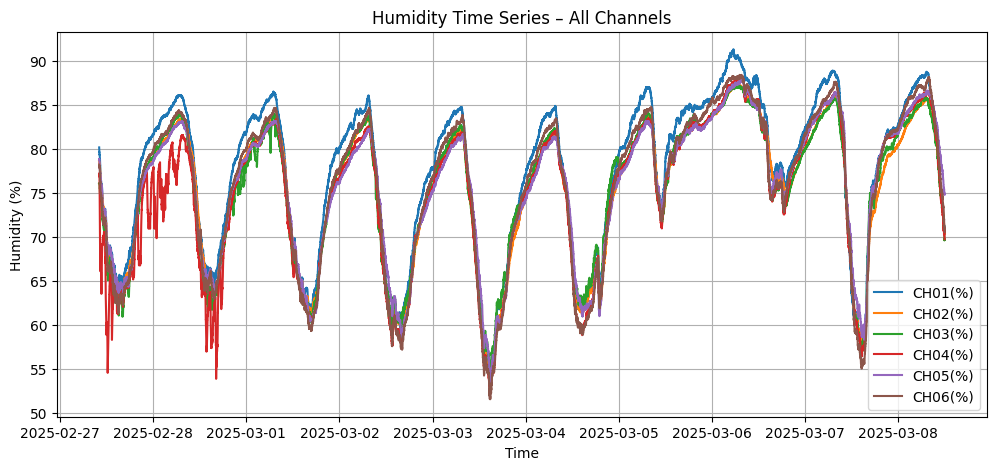

In [13]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
combined_df = combined_df.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in combined_df.columns:
    plt.plot(combined_df.index, combined_df[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# Select multiple channels
channels = [col for col in combined_df.columns if col.startswith('CH') and col.endswith('(%)')]
y = combined_df[channels].copy()

# Apply first-order differencing to the time series y to achieve stationarity
y_diff = y.diff().dropna()

# Check stationarity using the ADF test
adf_result = pd.DataFrame({col: adf_test_results(y_diff[col]) for col in y_diff.columns}).T
print(adf_result)
print(adf_result)

        ADF Statistic p-value  \
CH01(%)    -14.157771     0.0   
CH02(%)    -11.570427     0.0   
CH03(%)    -17.516912     0.0   
CH04(%)    -20.485715     0.0   
CH05(%)    -14.367134     0.0   
CH06(%)    -13.712145     0.0   

                                           Critical Values is_stationary  
CH01(%)  {'1%': -3.430517013017757, '5%': -2.8616138158...          True  
CH02(%)  {'1%': -3.430517017283361, '5%': -2.8616138177...          True  
CH03(%)  {'1%': -3.430516991693008, '5%': -2.8616138064...          True  
CH04(%)  {'1%': -3.430517004487204, '5%': -2.8616138121...          True  
CH05(%)  {'1%': -3.430517017283361, '5%': -2.8616138177...          True  
CH06(%)  {'1%': -3.430517013017757, '5%': -2.8616138158...          True  
        ADF Statistic p-value  \
CH01(%)    -14.157771     0.0   
CH02(%)    -11.570427     0.0   
CH03(%)    -17.516912     0.0   
CH04(%)    -20.485715     0.0   
CH05(%)    -14.367134     0.0   
CH06(%)    -13.712145     0.0   

           

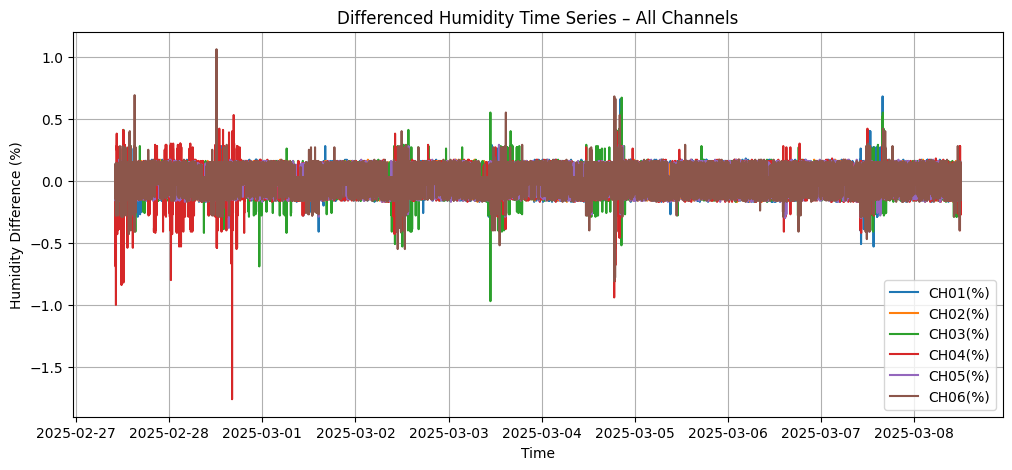

In [16]:
plt.figure(figsize=(12,5))
for col in y_diff.columns:
    plt.plot(y_diff.index, y_diff[col], label=col)

plt.title("Differenced Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity Difference (%)")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Forecast the next 10 periods for each channel using auto ARIMA on the differenced series
forecast_horizon = 10
forecasts = {}
for channel in channels:
    model = pm.auto_arima(y_diff[channel])
    diff_forecast = model.predict(n_periods=forecast_horizon)
    # Integrate back to original scale by cumulatively summing from the last value of y
    last_value = y[channel].iloc[-1]
    # Forecast the next 10 periods for each channel using auto ARIMA on the differenced series
    forecast_horizon = 10
    forecasts = {}
    for channel in channels:
        model = pm.auto_arima(y_diff[channel])
        diff_forecast = model.predict(n_periods=forecast_horizon)
        # Integrate back to original scale by cumulatively summing from the last value of y
        last_value = y[channel].iloc[-1]
        original_forecast = [last_value + diff_forecast.iloc[0]]
        for i in range(1, len(diff_forecast)):
            original_forecast.append(original_forecast[-1] + diff_forecast.iloc[i])
        forecasts[channel] = original_forecast

    # Display forecasts
    forecast_df = pd.DataFrame(forecasts)
    print(forecast_df)
    for i in range(1, len(diff_forecast)):
        original_forecast.append(original_forecast[-1] + diff_forecast.iloc[i])
    forecasts[channel] = original_forecast

# Display forecasts
forecast_df = pd.DataFrame(forecasts)
print(forecast_df)

KeyboardInterrupt: 